# Iris Unsupervised Clustering

This notebook explores Iris using unsupervised methods only.
The target column is held out from all fitting steps and used
only for post-hoc evaluation metrics.

In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

project_root = Path.cwd()
if not (project_root / 'src').exists() and project_root.parent.exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.analysis.kmeans import fit_kmeans
from src.analysis.kmeans import posthoc_label_metrics
from src.analysis.kmeans import score_kmeans
from src.utils.data import load_iris_features

sns.set_theme(style='whitegrid')

In [11]:
X, y = load_iris_features()
print('Feature shape:', X.shape)
print('Target shape:', y.shape)
X.head()

Feature shape: (150, 4)
Target shape: (150,)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [12]:
missing = X.isna().sum()
print('Missing values by column:')
print(missing)

X.describe().T

Missing values by column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaled feature matrix shape:', X_scaled.shape)

Scaled feature matrix shape: (150, 4)


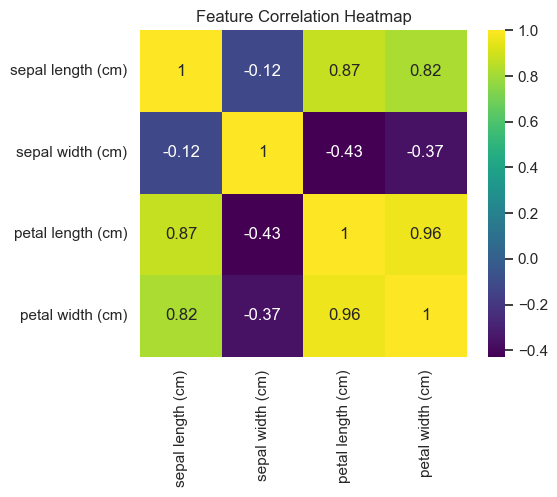

In [14]:
plt.figure(figsize=(6, 5))
corr = X.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='viridis', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

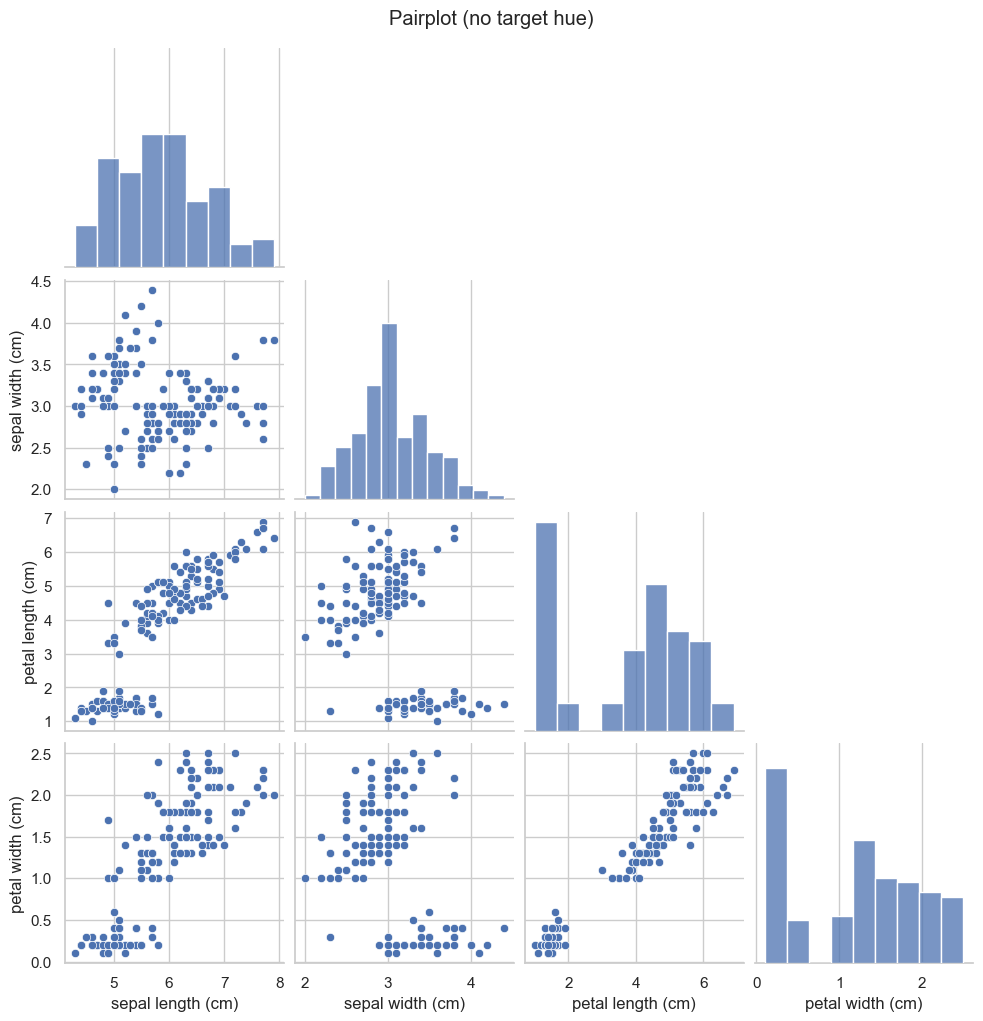

In [15]:
sns.pairplot(X, corner=True, diag_kind='hist')
plt.suptitle('Pairplot (no target hue)', y=1.02)
plt.show()

In [16]:
k_values = list(range(2, 9))
inertias = []
silhouettes = []
calinski_harabasz_scores = []
davies_bouldin_scores = []
cluster_balance_scores = []

for k in k_values:
    model = fit_kmeans(X_scaled, n_clusters=k, random_state=42)
    inertias.append(float(model.inertia_))
    score = score_kmeans(X_scaled, model.labels_)
    silhouettes.append(score['silhouette'])
    calinski_harabasz_scores.append(score['calinski_harabasz'])
    davies_bouldin_scores.append(score['davies_bouldin'])

    counts = np.bincount(model.labels_, minlength=k).astype(float)
    proportions = counts / counts.sum()
    # Normalized entropy in [0, 1]; higher means more balanced cluster sizes.
    balance_score = float(
        -(proportions * np.log(proportions + 1e-12)).sum() / np.log(k)
    )
    cluster_balance_scores.append(balance_score)

# Baseline for transparency: single-metric silhouette choice.
k_silhouette = k_values[int(np.argmax(silhouettes))]

# Stability is kept as a diagnostic signal, not a hard selection criterion.
seed_values = [7, 13, 21, 42, 84]
silhouette_runs = []
for seed in seed_values:
    run_scores = []
    for k in k_values:
        model = fit_kmeans(X_scaled, n_clusters=k, random_state=seed)
        score = score_kmeans(X_scaled, model.labels_)
        run_scores.append(score['silhouette'])
    silhouette_runs.append(run_scores)

silhouette_runs_arr = np.asarray(silhouette_runs, dtype=float)
silhouette_std = silhouette_runs_arr.std(axis=0)

metrics_df = pd.DataFrame(
    {
        'k': k_values,
        'inertia': inertias,
        'silhouette': silhouettes,
        'calinski_harabasz': calinski_harabasz_scores,
        'davies_bouldin': davies_bouldin_scores,
        'cluster_balance': cluster_balance_scores,
        'silhouette_std_seeded': silhouette_std,
    }
)

# Elbow proxy: farthest point from the line between first and last inertia points.
ks = metrics_df['k'].to_numpy(dtype=float)
ys = metrics_df['inertia'].to_numpy(dtype=float)
x1, y1 = ks[0], ys[0]
x2, y2 = ks[-1], ys[-1]
denom = np.hypot(y2 - y1, x2 - x1)
if denom == 0:
    elbow_k = int(ks[0])
else:
    distances = np.abs((y2 - y1) * ks - (x2 - x1) * ys + x2 * y1 - y2 * x1) / denom
    elbow_k = int(ks[np.argmax(distances)])

metrics_df['rank_silhouette'] = metrics_df['silhouette'].rank(ascending=False, method='min')
metrics_df['rank_calinski_harabasz'] = metrics_df['calinski_harabasz'].rank(
    ascending=False, method='min'
)
metrics_df['rank_davies_bouldin'] = metrics_df['davies_bouldin'].rank(
    ascending=True, method='min'
)
metrics_df['rank_cluster_balance'] = metrics_df['cluster_balance'].rank(
    ascending=False, method='min'
)

# Consensus across separation, compactness, and non-trivial partition structure.
metrics_df['rank_sum'] = (
    metrics_df['rank_silhouette']
    + metrics_df['rank_calinski_harabasz']
    + metrics_df['rank_davies_bouldin']
    + metrics_df['rank_cluster_balance']
)

top_rank = float(metrics_df['rank_sum'].min())
tied = metrics_df.loc[metrics_df['rank_sum'] == top_rank, 'k'].astype(int).tolist()
k_consensus = elbow_k if elbow_k in tied else tied[0]
k_best = int(k_consensus)

print('Best k by silhouette only:', k_silhouette)
print('Best k by robust consensus:', k_consensus)
print('Elbow k:', elbow_k)
print('Tied k values at best rank:', tied)
display(
    metrics_df[
        [
            'k',
            'inertia',
            'silhouette',
            'calinski_harabasz',
            'davies_bouldin',
            'cluster_balance',
            'silhouette_std_seeded',
            'rank_sum',
        ]
    ].round(4)
)

Best k by silhouette only: 2
Best k by robust consensus: 3
Elbow k: 3
Tied k values at best rank: [3]


,k,inertia,silhouette,calinski_harabasz,davies_bouldin,cluster_balance,silhouette_std_seeded,rank_sum
0,2,222.3617,0.5818,251.3493,0.5933,0.9183,0.0000,10.0
1,3,139.8205,0.4599,241.9044,0.8336,0.9989,0.0002,7.0
2,4,114.0923,0.3845,207.2664,0.8772,0.9581,0.0004,13.0
3,5,90.8076,0.3455,203.2674,0.9452,0.9722,0.0017,15.0
4,6,80.0222,0.3220,187.1401,1.0584,0.9721,0.0015,22.0
5,7,71.0334,0.3277,177.4803,0.9900,0.9446,0.0063,23.0
6,8,62.5149,0.3417,174.4106,0.9070,0.9185,0.0057,22.0


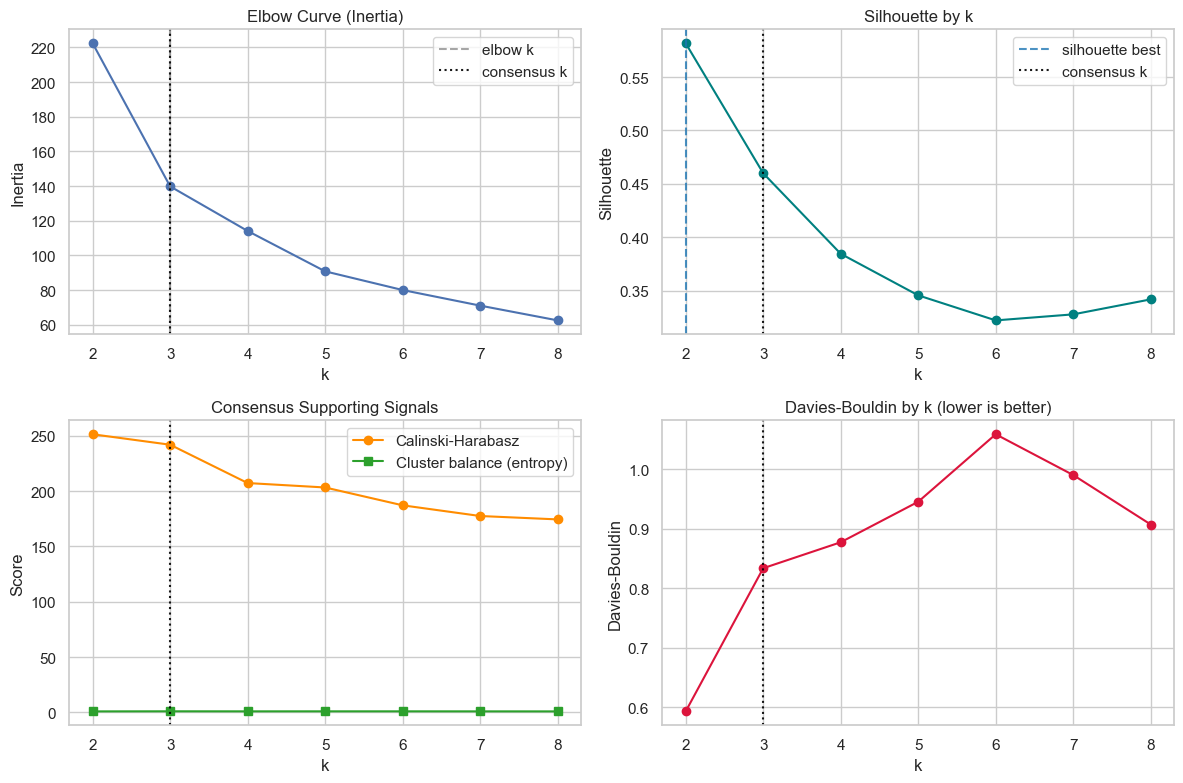

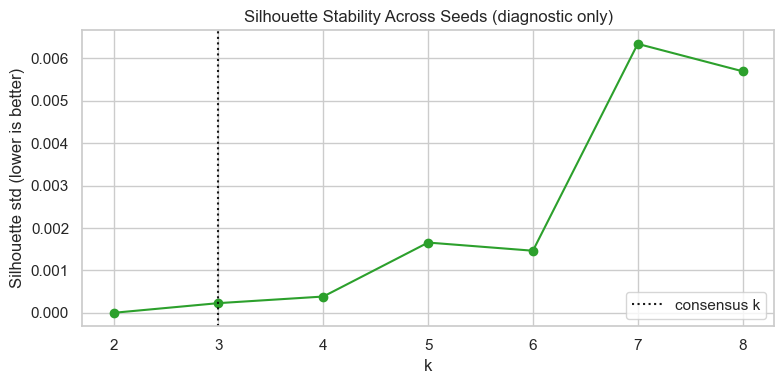

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(k_values, inertias, marker='o')
axes[0, 0].axvline(elbow_k, linestyle='--', color='gray', alpha=0.7, label='elbow k')
axes[0, 0].axvline(k_consensus, linestyle=':', color='black', alpha=0.9, label='consensus k')
axes[0, 0].set_title('Elbow Curve (Inertia)')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].legend()

axes[0, 1].plot(k_values, silhouettes, marker='o', color='teal')
axes[0, 1].axvline(k_silhouette, linestyle='--', color='tab:blue', alpha=0.8, label='silhouette best')
axes[0, 1].axvline(k_consensus, linestyle=':', color='black', alpha=0.9, label='consensus k')
axes[0, 1].set_title('Silhouette by k')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Silhouette')
axes[0, 1].legend()

axes[1, 0].plot(k_values, calinski_harabasz_scores, marker='o', color='darkorange', label='Calinski-Harabasz')
axes[1, 0].plot(k_values, cluster_balance_scores, marker='s', color='tab:green', label='Cluster balance (entropy)')
axes[1, 0].axvline(k_consensus, linestyle=':', color='black', alpha=0.9)
axes[1, 0].set_title('Consensus Supporting Signals')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('Score')
axes[1, 0].legend()

axes[1, 1].plot(k_values, davies_bouldin_scores, marker='o', color='crimson')
axes[1, 1].axvline(k_consensus, linestyle=':', color='black', alpha=0.9)
axes[1, 1].set_title('Davies-Bouldin by k (lower is better)')
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('Davies-Bouldin')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_std, marker='o', color='tab:green')
plt.axvline(k_consensus, linestyle=':', color='black', alpha=0.9, label='consensus k')
plt.title('Silhouette Stability Across Seeds (diagnostic only)')
plt.xlabel('k')
plt.ylabel('Silhouette std (lower is better)')
plt.legend()
plt.tight_layout()
plt.show()

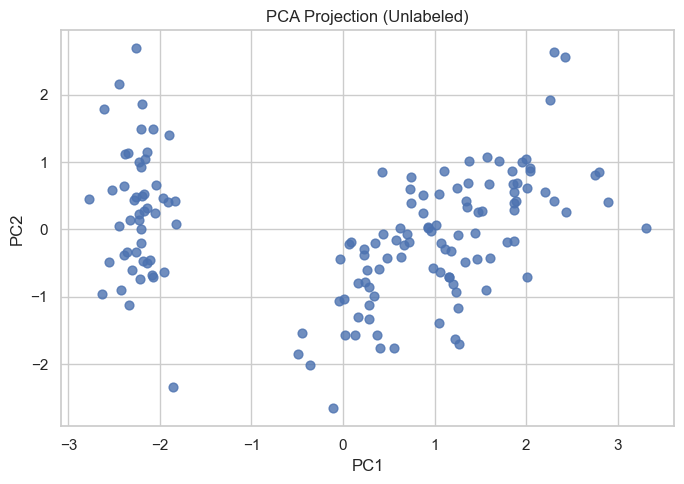

In [18]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.8, s=40)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (Unlabeled)')
plt.tight_layout()
plt.show()

In [19]:
selected_k = int(k_consensus)
print('Using consensus-selected k for final model:', selected_k)

final_model = fit_kmeans(X_scaled, n_clusters=selected_k, random_state=42)
cluster_labels = final_model.labels_
unsupervised_metrics = score_kmeans(X_scaled, cluster_labels)
pd.Series(unsupervised_metrics, name='value')

Using consensus-selected k for final model: 3


silhouette             0.459948
calinski_harabasz    241.904402
davies_bouldin         0.833595
Name: value, dtype: float64

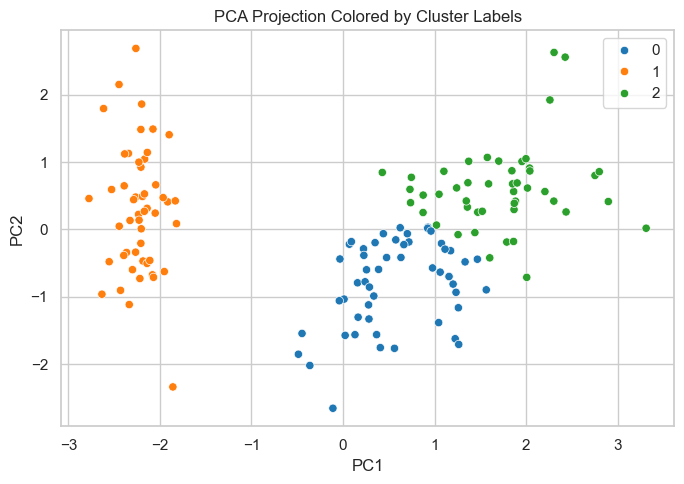

In [20]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_labels,
    palette='tab10',
    legend='full',
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection Colored by Cluster Labels')
plt.tight_layout()
plt.show()

In [21]:
posthoc = posthoc_label_metrics(
    y_true=y.to_numpy(),
    cluster_labels=cluster_labels,
)

summary = {
    'adjusted_rand_index': posthoc['adjusted_rand_index'],
    'normalized_mutual_info': posthoc['normalized_mutual_info'],
    'v_measure': posthoc['v_measure'],
    'mapped_accuracy': posthoc['mapped_accuracy'],
    'mapped_macro_precision': posthoc['mapped_macro_precision'],
    'mapped_macro_recall': posthoc['mapped_macro_recall'],
    'mapped_macro_f1': posthoc['mapped_macro_f1'],
}

print('Post-hoc metrics (evaluation only):')
for key, value in summary.items():
    print(f'- {key}: {value:.4f}')

report_df = pd.DataFrame(posthoc['mapped_classification_report']).T
report_df

Post-hoc metrics (evaluation only):
- adjusted_rand_index: 0.6201
- normalized_mutual_info: 0.6595
- v_measure: 0.6595
- mapped_accuracy: 0.8333
- mapped_macro_precision: 0.8339
- mapped_macro_recall: 0.8333
- mapped_macro_f1: 0.8332


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,50.000000
1,0.735849,0.780000,0.757282,50.000000
2,0.765957,0.720000,0.742268,50.000000
accuracy,0.833333,0.833333,0.833333,0.833333
macro avg,0.833936,0.833333,0.833183,150.000000
weighted avg,0.833936,0.833333,0.833183,150.000000


## Recap

- Model fitting, scaling, PCA, and k selection used only feature data.
- We keep silhouette-only k as a transparent baseline.
- Final k uses a consensus of inertia elbow, separation/compactness metrics,
  and a cluster-balance criterion to avoid trivial one-vs-rest partitions.
- Target-based metrics are post-hoc diagnostics only and are not used
  for training decisions.